<a href="https://colab.research.google.com/github/truonggiaky71-rgb/BTVN1/blob/main/btvn_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
pip install scikit-fuzzy


Giá đi xe:50.000 VND
Điểm thưởng cho tài xế: 8.81


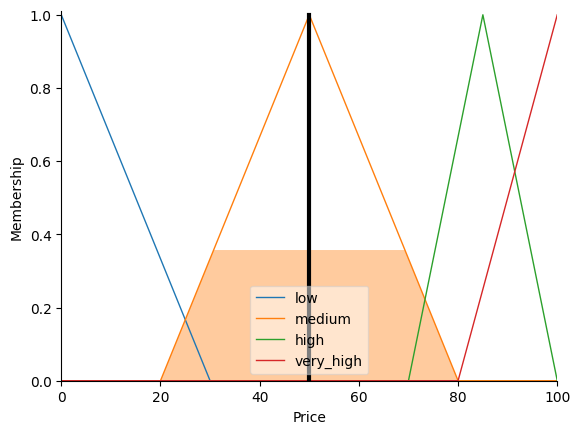

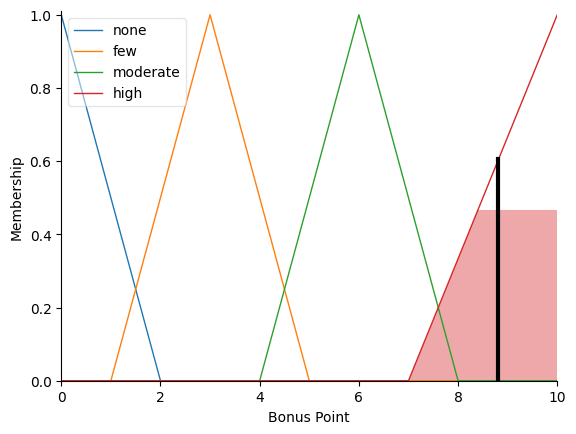

In [26]:
#2.11

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

RD = ctrl.Antecedent(np.arange(0, 51.1, 0.1), 'Ride Distance')
TC = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Traffic Condition')
DL = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Demand Level')
WC = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Weather Condition')
CR = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'Customer Rating')
RP = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Ride Punctuality')

Price = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'Price')
BP = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'Bonus Point')

RD['short'] = fuzz.trimf(RD.universe, [0, 0, 3])
RD['medium'] = fuzz.trimf(RD.universe, [2, 5, 8])
RD['long'] = fuzz.trimf(RD.universe, [6, 13, 20])
RD['very_long'] = fuzz.trimf(RD.universe, [15, 50, 50])

TC['low'] = fuzz.trimf(TC.universe, [0, 0, 30])
TC['medium'] = fuzz.trimf(TC.universe, [20, 45, 70])
TC['high'] = fuzz.trimf(TC.universe, [60, 100, 100])

DL['low'] = fuzz.trimf(DL.universe, [0, 0, 30])
DL['medium'] = fuzz.trimf(DL.universe, [20, 45, 70])
DL['high'] = fuzz.trimf(DL.universe, [60, 100, 100])

WC['good'] = fuzz.trimf(WC.universe, [0, 0, 5])
WC['moderate'] = fuzz.trimf(WC.universe, [3, 5, 7])
WC['bad'] = fuzz.trimf(WC.universe, [5, 10, 10])

CR['poor'] = fuzz.trimf(CR.universe, [1, 1, 2.5])
CR['average'] = fuzz.trimf(CR.universe, [2, 3, 4])
CR['good'] = fuzz.trimf(CR.universe, [3.5, 5, 5])

RP['late'] = fuzz.trimf(RP.universe, [0, 0, 50])
RP['on_time'] = fuzz.trimf(RP.universe, [40, 60, 80])
RP['early'] = fuzz.trimf(RP.universe, [70, 100, 100])

Price['low'] = fuzz.trimf(Price.universe, [0, 0, 30])
Price['medium'] = fuzz.trimf(Price.universe, [20, 50, 80])
Price['high'] = fuzz.trimf(Price.universe, [70, 85, 100])
Price['very_high'] = fuzz.trimf(Price.universe, [80, 100, 100])

BP['none'] = fuzz.trimf(BP.universe, [0, 0, 2])
BP['few'] = fuzz.trimf(BP.universe, [1, 3, 5])
BP['moderate'] = fuzz.trimf(BP.universe, [4, 6, 8])
BP['high'] = fuzz.trimf(BP.universe, [7, 10, 10])

rule1 = ctrl.Rule(RD['short'] & TC['low'] & DL['low'], Price['low'])
rule2 = ctrl.Rule(RD['short'] & TC['medium'] & DL['high'], Price['medium'])
rule3 = ctrl.Rule(RD['medium'] & TC['high'] & DL['high'], Price['high'])
rule4 = ctrl.Rule(RD['long'] & TC['medium'] & WC['good'], Price['medium'])
rule5 = ctrl.Rule(RD['long'] & TC['high'] & WC['bad'], Price['very_high'])
rule6 = ctrl.Rule(RD['very_long'] & TC['high'] & DL['high'], Price['very_high'])
rule7 = ctrl.Rule(RD['medium'] & TC['low'] & DL['low'], Price['medium'])
rule8 = ctrl.Rule(RD['short'] & TC['high'] & WC['bad'], Price['high'])
rule9 = ctrl.Rule(RD['very_long'] & WC['bad'], Price['very_high'])
rule10 = ctrl.Rule(RD['medium'] & TC['medium'] & WC['moderate'], Price['medium'])
rule11 = ctrl.Rule(CR['good'] & RP['early'], BP['high'])
rule12 = ctrl.Rule(CR['average'] & RP['on_time'] , BP['moderate'])
rule13 = ctrl.Rule(CR['poor'] & RP['late'], BP['none'])
rule14 = ctrl.Rule(RD['long'] & TC['high'] & RP['on_time'], BP['high'])
rule15 = ctrl.Rule(RD['medium'] & TC['medium'] & CR['good'], BP['moderate'])
rule16 = ctrl.Rule(CR['poor'] & RP['late'], BP['none'])
rule17 = ctrl.Rule(RD['very_long'] & WC['bad'] & CR['good'], BP['high'])
rule18 = ctrl.Rule(RD['short'] & CR['average'] & RP['on_time'], BP['few'])
rule19 = ctrl.Rule(RD['long'] & TC['high'] & RP['late'], BP['few'])
rule20 = ctrl.Rule(RD['medium'] & WC['moderate'] & CR['good'], BP['moderate'])

System_ctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,rule13,rule14,rule15,rule16,rule17,rule18,rule19,rule20])
System = ctrl.ControlSystemSimulation(System_ctrl)

System.input['Ride Distance'] = 8.5
System.input['Traffic Condition'] = 60
System.input['Demand Level'] = 70
System.input['Weather Condition'] = 2
System.input['Customer Rating'] = 4.2
System.input['Ride Punctuality'] = 85

System.compute()

print(f'Giá đi xe:{System.output['Price']:.3f} VND')
print(f'Điểm thưởng cho tài xế: {System.output['Bonus Point']:.2f}')
Price.view(sim=System)
BP.view(sim=System)

Tỷ lệ phần trăm chiết khấu: 55.00%


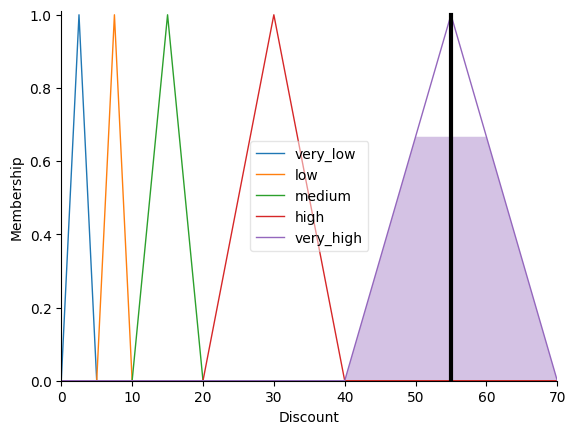

In [34]:
#2.12

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

SR = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'Store Rating')
SV = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Sales Volume')
PM = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Profit Margin')
SE = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Seasonal Event')
CD = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Competitor Discounts')

Discount = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'Discount')

SR['low'] = fuzz.trimf(SR.universe, [1, 1, 4])
SR['medium'] = fuzz.trimf(SR.universe, [4, 4.25, 4.5])
SR['high'] = fuzz.trimf(SR.universe, [4.5, 5.0, 5.0])

SV['low'] = fuzz.trimf(SV.universe, [0, 0, 40])
SV['medium'] = fuzz.trimf(SV.universe, [20, 50, 80])
SV['high'] = fuzz.trimf(SV.universe, [60, 100, 100])

PM['low'] = fuzz.trimf(PM.universe, [0, 0, 40])
PM['medium'] = fuzz.trimf(PM.universe, [20, 50, 80])
PM['high'] = fuzz.trimf(PM.universe, [60, 100, 100])

SE['none'] = fuzz.trimf(SE.universe, [0, 0, 3])
SE['moderate'] = fuzz.trimf(SE.universe, [2, 5, 8])
SE['high'] = fuzz.trimf(SE.universe, [7, 10, 10])

CD['low'] = fuzz.trimf(CD.universe, [0, 0, 40])
CD['medium'] = fuzz.trimf(CD.universe, [20, 50, 80])
CD['high'] = fuzz.trimf(CD.universe, [60, 100, 100])

Discount['very_low'] = fuzz.trimf(Discount.universe, [0, 2.5, 5])
Discount['low'] = fuzz.trimf(Discount.universe, [5, 7.5, 10])
Discount['medium'] = fuzz.trimf(Discount.universe, [10, 15, 20])
Discount['high'] = fuzz.trimf(Discount.universe, [20, 30, 40])
Discount['very_high'] = fuzz.trimf(Discount.universe, [40, 55, 70])

rule1 = ctrl.Rule(SR['high'] & SV['high'] & PM['high'], Discount['very_low'])
rule2 = ctrl.Rule(SR['low'] & SV['low'] & PM['high'], Discount['high'])
rule3 = ctrl.Rule(SE['high'] & CD['high'], Discount['very_high'])
rule4 = ctrl.Rule(SR['medium'] & SV['medium'] & PM['medium'], Discount['medium'])
rule5 = ctrl.Rule(CD['low'] & PM['low'] & SV['high'], Discount['very_low'])
rule6 = ctrl.Rule(SR['low'] & SE['none'], Discount['medium'])
rule7 = ctrl.Rule(SV['low'] & PM['low'], Discount['very_high'])

System_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
System = ctrl.ControlSystemSimulation(System_ctrl)

System.input['Store Rating'] = 4.3
System.input['Sales Volume'] = 50
System.input['Profit Margin'] = 15
System.input['Seasonal Event'] = 9
System.input['Competitor Discounts'] = 87

System.compute()

print(f'Tỷ lệ phần trăm chiết khấu: {System.output["Discount"]:.2f}%')
Discount.view(sim=System)

Mức giảm giá :55.00%


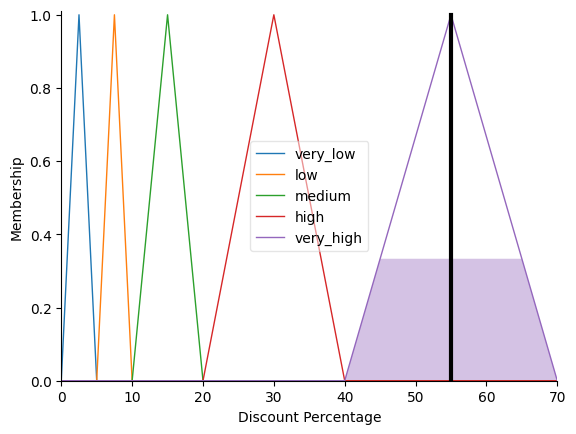

In [41]:
#2.13

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

PD = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Product Demand')
CPP = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Competitor Pricing Pressure')
SR = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store Reputation')
PM = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Profit Margin')
SD = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Seasonal Demand')

Discount = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'Discount Percentage')

PD['low'] = fuzz.trimf(PD.universe, [0, 0, 5])
PD['medium'] = fuzz.trimf(PD.universe, [4, 6, 8])
PD['high'] = fuzz.trimf(PD.universe, [7, 10, 10])

CPP['low'] = fuzz.trimf(CPP.universe, [0, 0, 5])
CPP['medium'] = fuzz.trimf(CPP.universe, [4,6,8])
CPP['high'] = fuzz.trimf(CPP.universe, [7, 10, 10])

SR['low'] = fuzz.trimf(SR.universe, [0, 0, 4])
SR['medium'] = fuzz.trimf(SR.universe, [4, 4.25, 4.5])
SR['high'] = fuzz.trimf(SR.universe, [4.5, 5, 5])

PM['low'] = fuzz.trimf(PM.universe, [0, 0, 40])
PM['medium'] = fuzz.trimf(PM.universe, [30, 55, 80])
PM['high'] = fuzz.trimf(PM.universe, [60, 100, 100])

SD['none'] = fuzz.trimf(SD.universe, [0, 0, 3])
SD['medium'] = fuzz.trimf(SD.universe, [2, 5, 8])
SD['high'] = fuzz.trimf(SD.universe, [7, 10, 10])

Discount['very_low'] = fuzz.trimf(Discount.universe, [0, 2.5, 5])
Discount['low'] = fuzz.trimf(Discount.universe, [5, 7.5, 10])
Discount['medium'] = fuzz.trimf(Discount.universe, [10, 15, 20])
Discount['high'] = fuzz.trimf(Discount.universe, [20, 30, 40])
Discount['very_high'] = fuzz.trimf(Discount.universe, [40, 55, 70])

rule1 = ctrl.Rule(PD['high'] & CPP['low'] & PM['low'], Discount['very_low'])
rule2 = ctrl.Rule(PD['low'] & CPP['high'] & PM['high'], Discount['high'])
rule3 = ctrl.Rule(SR['high'] & PM['medium'] & SD['high'], Discount['medium'])
rule4 = ctrl.Rule(CPP['high'] & SD['high'] & PM['high'], Discount['very_high'])
rule5 = ctrl.Rule(SR['low'] & PD['medium'] & PM['low'], Discount['medium'])
rule6 = ctrl.Rule(PD['high'] & SD['none'] & CPP['low'], Discount['very_low'])
rule7 = ctrl.Rule(PM['high'] & CPP['medium'] & SD['medium'], Discount['medium'])

System_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
System = ctrl.ControlSystemSimulation(System_ctrl)

System.input['Product Demand'] = 8
System.input['Competitor Pricing Pressure'] = 8
System.input['Store Reputation'] = 4.2
System.input['Profit Margin'] = 80
System.input['Seasonal Demand'] = 9

System.compute()

print(f'Mức giảm giá :{System.output['Discount Percentage']:.2f}%')
Discount.view(sim=System)

Số lượng đơn hàng cần kết hợp: 87.60 
Ưu tiên giao hàng: 87.75


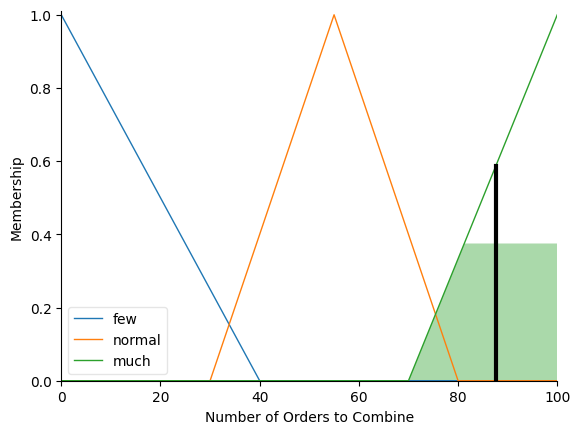

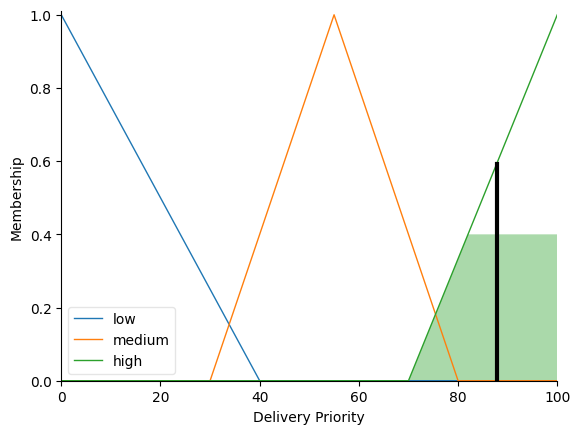

In [43]:
#2.14

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

OD = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Order Density')
DU = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Delivery Urgency')
DCL = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Driver Current Load')
TC = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Traffic Conditions')
PPD = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Profit Per Delivery')

NOC = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'Number of Orders to Combine')
DP = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'Delivery Priority')

OD['low'] = fuzz.trimf(OD.universe, [0, 0, 5])
OD['medium'] = fuzz.trimf(OD.universe, [3, 5, 7])
OD['high'] = fuzz.trimf(OD.universe, [5, 10, 10])

DU['low'] = fuzz.trimf(DU.universe, [0, 0, 5])
DU['medium'] = fuzz.trimf(DU.universe, [3, 5, 7])
DU['high'] = fuzz.trimf(DU.universe, [5, 10, 10])

DCL['low'] = fuzz.trimf(DCL.universe, [0, 0, 40])
DCL['medium'] = fuzz.trimf(DCL.universe, [30, 50, 70])
DCL['high'] = fuzz.trimf(DCL.universe, [60, 100, 100])

TC['low'] = fuzz.trimf(TC.universe, [0, 0, 5])
TC['medium'] = fuzz.trimf(TC.universe, [3, 5, 7])
TC['high'] = fuzz.trimf(TC.universe, [5, 10, 10])

PPD['low'] = fuzz.trimf(PPD.universe, [0, 0, 40])
PPD['medium'] = fuzz.trimf(PPD.universe, [30, 50, 70])
PPD['high'] = fuzz.trimf(PPD.universe, [60, 100, 100])

NOC['few'] = fuzz.trimf(NOC.universe, [0, 0, 40])
NOC['normal'] = fuzz.trimf(NOC.universe, [30, 55, 80])
NOC['much'] = fuzz.trimf(NOC.universe, [70, 100, 100])

DP['low'] = fuzz.trimf(DP.universe, [0, 0, 40])
DP['medium'] = fuzz.trimf(DP.universe, [30, 55, 80])
DP['high'] = fuzz.trimf(DP.universe, [70, 100, 100])

rule1 = ctrl.Rule(OD['high'] & DCL['low'] & TC['low'], NOC['much'])
rule2 = ctrl.Rule(OD['medium'] & TC['high']& DU['medium'], NOC['normal'])
rule3 = ctrl.Rule(DCL['high'] & OD['high'] & PPD['medium'], NOC['normal'])
rule4 = ctrl.Rule(OD['low'] & DU['high'] & TC['medium'], NOC['normal'])
rule5 = ctrl.Rule(PPD['high'] & DU['high'] & TC['high'], NOC['normal'])
rule6 = ctrl.Rule(DU['high'] & PPD['high'], DP['high'])
rule7 = ctrl.Rule(DU['medium'] & TC['medium'], DP['medium'])
rule8 = ctrl.Rule(DU['low'] & OD['high'] & PPD['low'], DP['low'])

System_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
System = ctrl.ControlSystemSimulation(System_ctrl)

System.input['Order Density'] = 8.5
System.input['Delivery Urgency'] = 7.0
System.input['Driver Current Load'] = 25
System.input['Traffic Conditions'] = 2.0
System.input['Profit Per Delivery'] = 80

System.compute()

print(f'Số lượng đơn hàng cần kết hợp: {System.output['Number of Orders to Combine']:.2f} ')
print(f'Ưu tiên giao hàng: {System.output['Delivery Priority']:.2f}')

NOC.view(sim=System)
DP.view(sim=System)